In [2]:
# import sys
# sys.executable

# !{sys.executable} -m pip install openpyxl

<a href="https://www.guttmacher.org/article/2018/01/policy-trends-states-2017">Link to Guttmacher</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
raw = pd.read_excel('data/GuttmacherInstituteAbortionDataByState.xlsx', sheet_name='Guttmacher', engine='openpyxl')
raw.columns = raw.columns.str.strip() # remove whitespace from column names
raw.head()

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613


<h3>Data Cleaning</h3>

In [3]:
# convert all non numeric data to np.nan
for col in raw.columns[1:]:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

In [4]:
raw.isna().sum() 

U.S. State                                                                                       0
% change in abortion rate, 2017-2020                                                             0
% change in the no. of abortion clinics, 2017-2020                                               0
% change in the no. of abortion providers, 2014-2017                                             0
% of all U.S. abortions, by state of occurrence, 2020                                            0
% of counties without a known abortion provider, 2014                                            0
% of counties without a known clinic, 2020                                                       0
% of residents obtaining abortions who traveled out of state for care, 2020                      0
% of women aged 15-44 living in a county without a clinic, 2020                                  0
% of women aged 15-44 living in a county without an abortion provider, 2014                      0
Abortion r

According to <a href="https://www.guttmacher.org/article/2018/01/policy-trends-states-2017">Guttmacher</a>, these are the states hostile against abortions in 2017.

In [5]:
extremely_hostile_states = [
    "Alabama", "Arkansas", "Georgia", "Indiana", "Iowa", "Kansas", "Kentucky",
    "Louisiana", "Mississippi", "Missouri", "Nebraska", "North Carolina",
    "North Dakota", "Ohio", "Oklahoma", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "West Virginia", "Wisconsin", "Wyoming"
]

hostile_states = [
    "Idaho", "Michigan", "Pennsylvania", "Virginia"
]

middle_ground_states = [
    "Alaska", "Colorado", "Montana", "Nevada", "New Mexico", "North Dakota", "West Virginia"
]

illegal = extremely_hostile_states + hostile_states + middle_ground_states

In [6]:
raw[raw['U.S. State'].isin(illegal)].isna().sum()

U.S. State                                                                                       0
% change in abortion rate, 2017-2020                                                             0
% change in the no. of abortion clinics, 2017-2020                                               0
% change in the no. of abortion providers, 2014-2017                                             0
% of all U.S. abortions, by state of occurrence, 2020                                            0
% of counties without a known abortion provider, 2014                                            0
% of counties without a known clinic, 2020                                                       0
% of residents obtaining abortions who traveled out of state for care, 2020                      0
% of women aged 15-44 living in a county without a clinic, 2020                                  0
% of women aged 15-44 living in a county without an abortion provider, 2014                      0
Abortion r

Considering a majority of the missing data comes from these states, we can assume that the unreported values are 0.

In [7]:
for i, state in enumerate(raw['U.S. State']):
    if state in illegal:
        raw.iloc[i] = raw.iloc[i].fillna(0)

In [8]:
raw.isna().sum()

U.S. State                                                                                      0
% change in abortion rate, 2017-2020                                                            0
% change in the no. of abortion clinics, 2017-2020                                              0
% change in the no. of abortion providers, 2014-2017                                            0
% of all U.S. abortions, by state of occurrence, 2020                                           0
% of counties without a known abortion provider, 2014                                           0
% of counties without a known clinic, 2020                                                      0
% of residents obtaining abortions who traveled out of state for care, 2020                     0
% of women aged 15-44 living in a county without a clinic, 2020                                 0
% of women aged 15-44 living in a county without an abortion provider, 2014                     0
Abortion rate (the n

In [9]:
uncategorized_states = [
    "Arizona", "California", "Connecticut", "Delaware", "District of Columbia",
    "Florida", "Hawaii", "Illinois", "Maine", "Maryland", "Massachusetts",
    "Minnesota", "New Hampshire", "New Jersey", "New York", "Oregon",
    "Rhode Island", "Vermont", "Washington"
]

In [10]:
mask = raw['U.S. State'].isin(uncategorized_states)

for col in raw.columns:
    if col != 'U.S. State':
        mean_value = raw.loc[mask, col].mean(skipna=True)
        raw.loc[mask, col] = raw.loc[mask, col].fillna(mean_value)

In [11]:
raw.isna().sum().sum()

0

In [12]:
df = raw.copy()

<h3>EDA</h3>

In [13]:
df.head()

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0.0,22.0,0.0,9.0,22.0
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835.0,0.0,216.0,835.0,216.0
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13.0,28.0,11.0,14.0,40.0
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0.0,0.0,0.0,0.0,0.0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466.0,0.0,32613.0,88466.0,32613.0


In [14]:
# Step 1: Compute correlation matrix
corr_matrix = df.drop(columns='U.S. State').corr()

# Step 2: Unstack and filter
high_corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

# Step 3: Filter by correlation threshold
high_corr_pairs = high_corr_pairs[high_corr_pairs.abs() > 0.4]

# ✅ Step 4: Deduplicate symmetric pairs (A-B and B-A)
# Normalize tuple keys by sorting them
high_corr_pairs.index = [tuple(sorted(pair)) for pair in high_corr_pairs.index]

# Drop duplicates based on the normalized (sorted) index
high_corr_pairs = high_corr_pairs[~high_corr_pairs.index.duplicated(keep='first')]

high_corr_pairs


(% of all U.S. abortions, by state of occurrence, 2020, No. of abortions, by state of occurrence, 2020)                                                  0.999961
(No. of abortions among women aged 15-19, by state of residence, 2017, No. of abortions, by state of residence, 2020)                                    0.995772
(No. of abortions among women aged 15-17, by state of residence, 2017, No. of abortions among women aged 18-19, by state of residence, 2017)             0.994962
(No. of abortions, by state of occurrence, 2020, No. of abortions, by state of residence, 2020)                                                          0.994503
(% of all U.S. abortions, by state of occurrence, 2020, No. of abortions, by state of residence, 2020)                                                   0.994396
                                                                                                                                                           ...   
(% of counties without a kno

<Figure size 1000x1000 with 0 Axes>

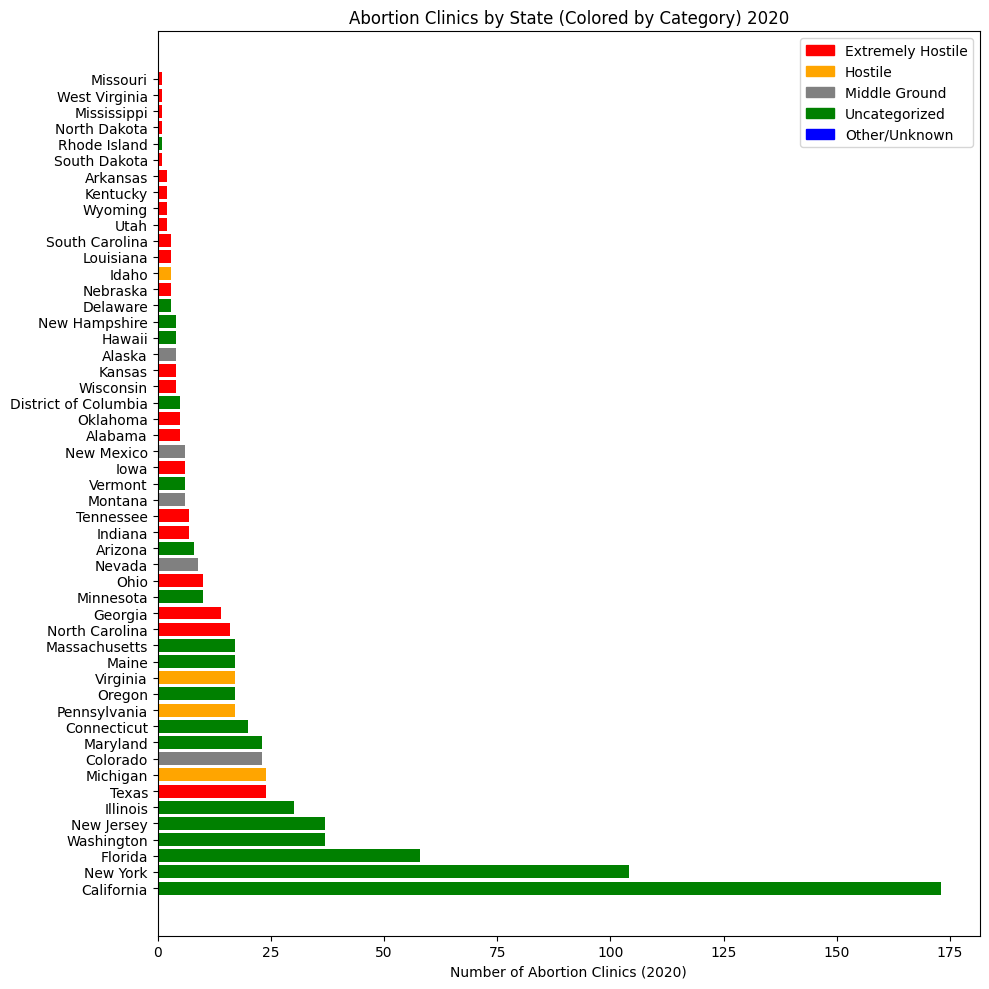

In [15]:
plt.figure(figsize=(10, 10))

def get_color(state):
    if state in extremely_hostile_states:
        return "red"
    elif state in hostile_states:
        return "orange"
    elif state in middle_ground_states:
        return "gray"
    elif state in uncategorized_states:
        return "green"
    else:
        return "blue"
        
# Sort data
sorted_df = df.sort_values("No. of abortion clinics, 2020", ascending=False)

# Assign colors
colors = [get_color(state) for state in sorted_df["U.S. State"]]

# Plot
plt.figure(figsize=(10, 10))
plt.barh(
    y=sorted_df["U.S. State"],
    width=sorted_df["No. of abortion clinics, 2020"],
    color=colors
)
plt.xlabel("Number of Abortion Clinics (2020)")
plt.title("Abortion Clinics by State (Colored by Category) 2020")

# Create custom legend
legend_patches = [
    mpatches.Patch(color='red', label='Extremely Hostile'),
    mpatches.Patch(color='orange', label='Hostile'),
    mpatches.Patch(color='gray', label='Middle Ground'),
    mpatches.Patch(color='green', label='Uncategorized'),
    mpatches.Patch(color='blue', label='Other/Unknown')
]
plt.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

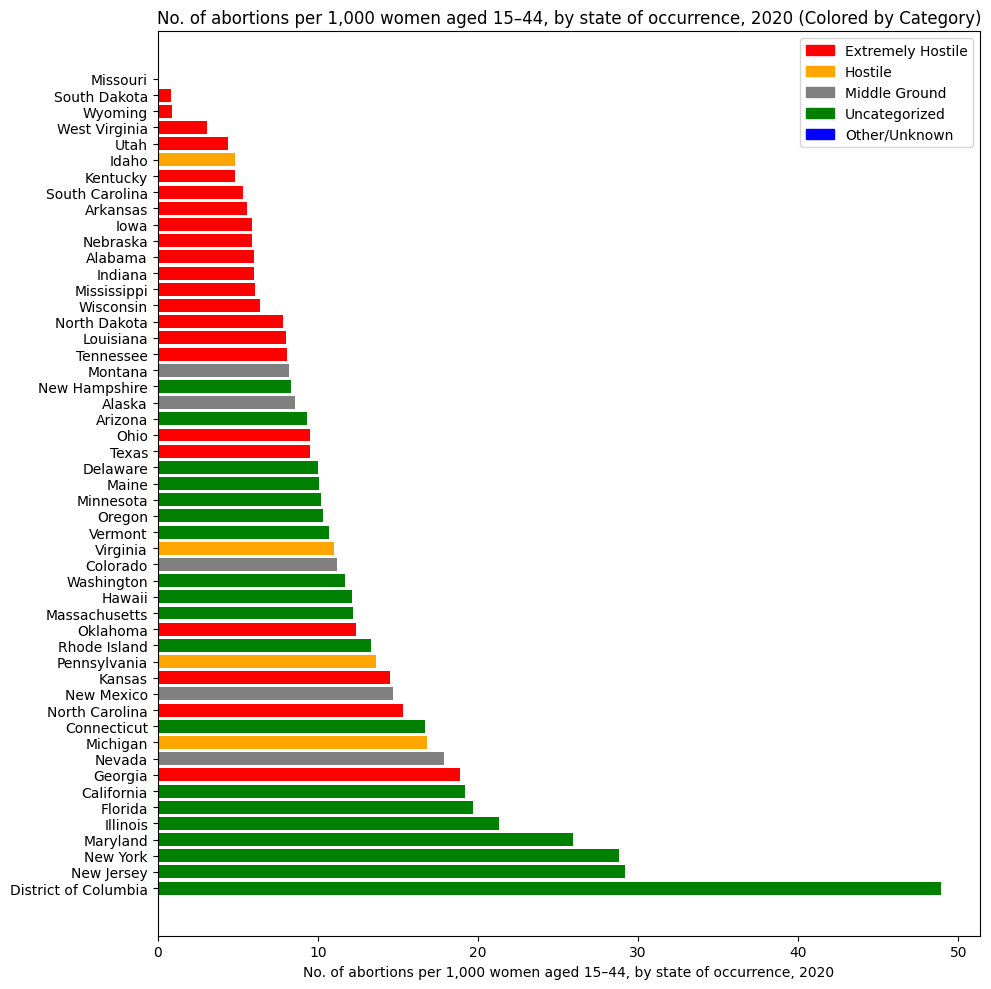

In [16]:
plt.figure(figsize=(10, 10))

def get_color(state):
    if state in extremely_hostile_states:
        return "red"
    elif state in hostile_states:
        return "orange"
    elif state in middle_ground_states:
        return "gray"
    elif state in uncategorized_states:
        return "green"
    else:
        return "blue"
        
# Sort data
sorted_df = df.sort_values("No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020", ascending=False)

# Assign colors
colors = [get_color(state) for state in sorted_df["U.S. State"]]

# Plot
plt.figure(figsize=(10, 10))
plt.barh(
    y=sorted_df["U.S. State"],
    width=sorted_df["No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020"],
    color=colors
)
plt.xlabel("No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020")
plt.title("No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020 (Colored by Category)")

# Create custom legend
legend_patches = [
    mpatches.Patch(color='red', label='Extremely Hostile'),
    mpatches.Patch(color='orange', label='Hostile'),
    mpatches.Patch(color='gray', label='Middle Ground'),
    mpatches.Patch(color='green', label='Uncategorized'),
    mpatches.Patch(color='blue', label='Other/Unknown')
]
plt.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

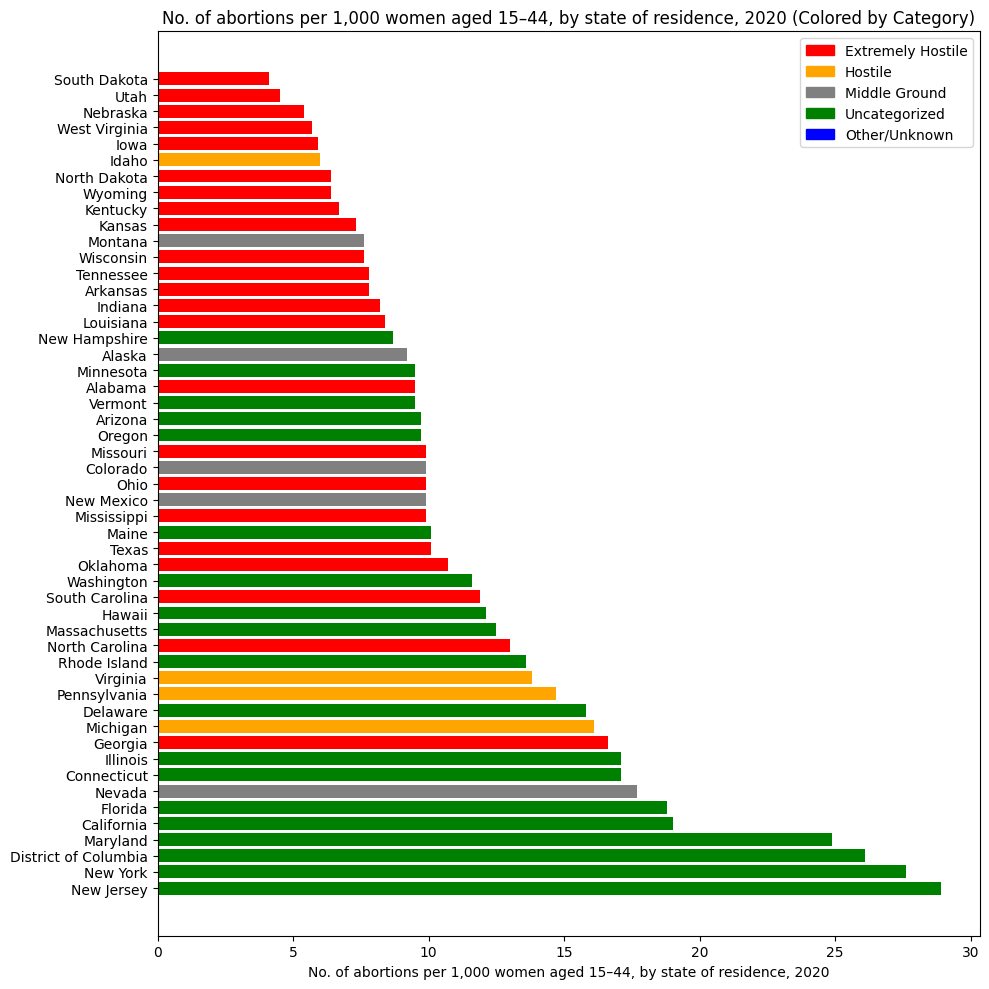

In [17]:
plt.figure(figsize=(10, 10))

def get_color(state):
    if state in extremely_hostile_states:
        return "red"
    elif state in hostile_states:
        return "orange"
    elif state in middle_ground_states:
        return "gray"
    elif state in uncategorized_states:
        return "green"
    else:
        return "blue"
        
# Sort data
sorted_df = df.sort_values("No. of abortions per 1,000 women aged 15–44, by state of residence, 2020", ascending=False)

# Assign colors
colors = [get_color(state) for state in sorted_df["U.S. State"]]

# Plot
plt.figure(figsize=(10, 10))
plt.barh(
    y=sorted_df["U.S. State"],
    width=sorted_df["No. of abortions per 1,000 women aged 15–44, by state of residence, 2020"],
    color=colors
)
plt.xlabel("No. of abortions per 1,000 women aged 15–44, by state of residence, 2020")
plt.title("No. of abortions per 1,000 women aged 15–44, by state of residence, 2020 (Colored by Category)")

# Create custom legend
legend_patches = [
    mpatches.Patch(color='red', label='Extremely Hostile'),
    mpatches.Patch(color='orange', label='Hostile'),
    mpatches.Patch(color='gray', label='Middle Ground'),
    mpatches.Patch(color='green', label='Uncategorized'),
    mpatches.Patch(color='blue', label='Other/Unknown')
]
plt.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

From these graphs you can see that although New Jersey has the highest No. of abortions it has fewer than 50 clinics. Also, The District of Columbia is surrounded by hostile states and has the highest No. of Abortions per 1000 women. 

<Figure size 1000x1000 with 0 Axes>

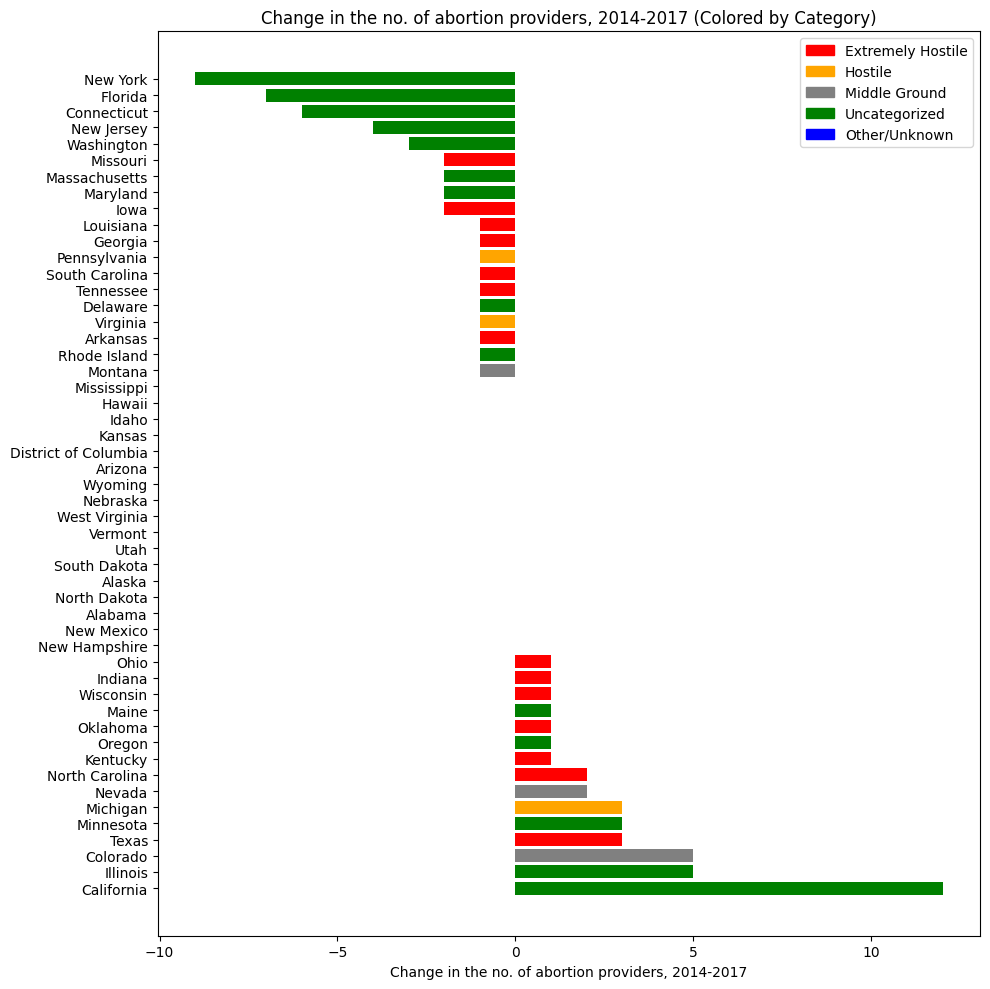

In [18]:
plt.figure(figsize=(10, 10))

def get_color(state):
    if state in extremely_hostile_states:
        return "red"
    elif state in hostile_states:
        return "orange"
    elif state in middle_ground_states:
        return "gray"
    elif state in uncategorized_states:
        return "green"
    else:
        return "blue"
        
# Sort data
sorted_df = df.sort_values("Change in the no. of abortion clinics, 2017-2020", ascending=False)

# Assign colors
colors = [get_color(state) for state in sorted_df["U.S. State"]]

# Plot
plt.figure(figsize=(10, 10))
plt.barh(
    y=sorted_df["U.S. State"],
    width=sorted_df["Change in the no. of abortion clinics, 2017-2020"],
    color=colors
)
plt.xlabel("Change in the no. of abortion providers, 2014-2017")
plt.title("Change in the no. of abortion providers, 2014-2017 (Colored by Category)")

# Create custom legend
legend_patches = [
    mpatches.Patch(color='red', label='Extremely Hostile'),
    mpatches.Patch(color='orange', label='Hostile'),
    mpatches.Patch(color='gray', label='Middle Ground'),
    mpatches.Patch(color='green', label='Uncategorized'),
    mpatches.Patch(color='blue', label='Other/Unknown')
]
plt.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

<h3>Supporting Abortion Access</h3>

“Access to abortion clinics is essential for reducing out-of-state travel and improving healthcare equity.”

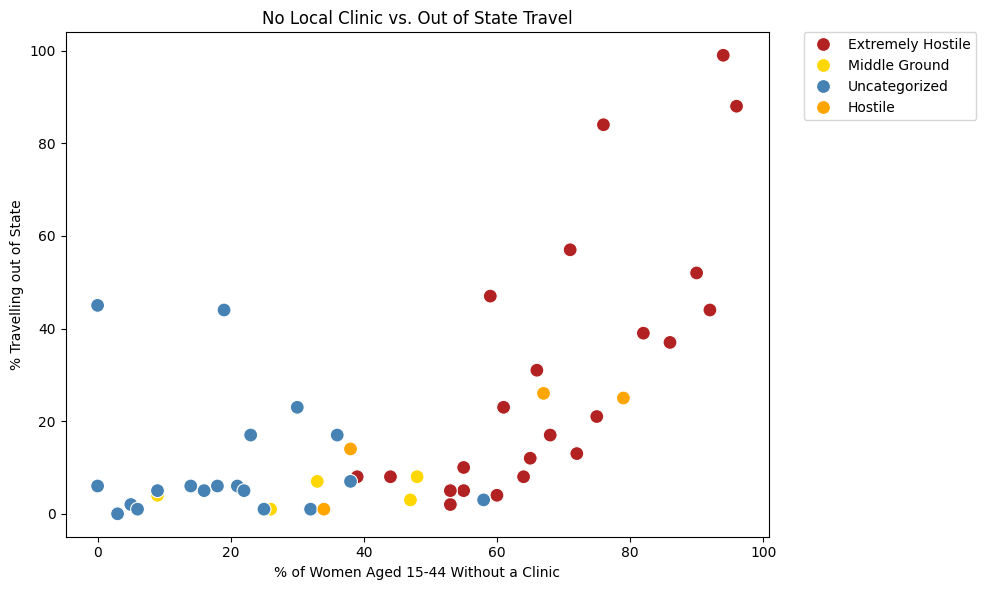

In [32]:
def classify_state(state):
    if state in extremely_hostile_states:
        return 'Extremely Hostile'
    elif state in hostile_states:
        return 'Hostile'
    elif state in middle_ground_states:
        return 'Middle Ground'
    elif state in uncategorized_states:
        return 'Uncategorized'
    else:
        return 'Unknown'

df['Policy Category'] = df['U.S. State'].apply(classify_state)

custom_palette = {
    'Extremely Hostile': '#B22222',  # Firebrick / Dark Red
    'Hostile': '#FFA500',            # Orange
    'Middle Ground': '#FFD700',      # Gold
    'Uncategorized': '#4682B4'       # Steel Blue (or use 'gray')
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='% of women aged 15-44 living in a county without a clinic, 2020',
    y='% of residents obtaining abortions who traveled out of state for care, 2020',
    hue='Policy Category',
    palette=custom_palette,  # optional: choose a palette with enough distinct colors
    s=100  # optional: set size of dots
)

plt.title('No Local Clinic vs. Out of State Travel')
plt.ylabel('% Travelling out of State')
plt.xlabel('% of Women Aged 15-44 Without a Clinic')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

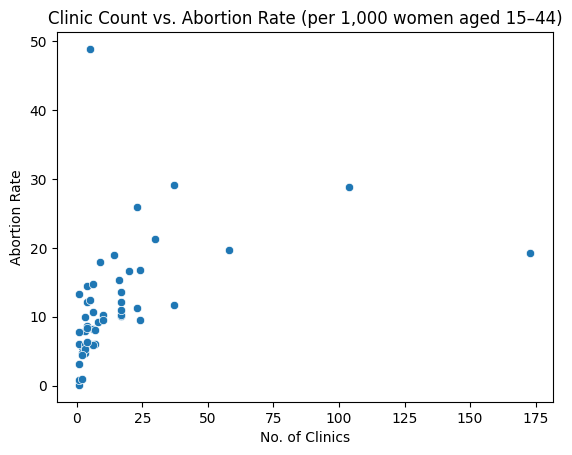

In [20]:
sns.scatterplot(
    x=df['No. of abortion clinics, 2020'],
    y=df['No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020']
)

plt.title('Clinic Count vs. Abortion Rate (per 1,000 women aged 15–44)')
plt.xlabel('No. of Clinics')
plt.ylabel('Abortion Rate')
plt.show()

Higher No. of Clinics means greater access allows for more needs to be met. 

<h3>Clinic Reduction is not as impactful</h3>

“Restricting abortion clinics does not significantly reduce abortion numbers—it just changes where people get care.”

🔵 Counter-Proposition 1:
“Reducing the number of clinics does not reduce abortion access—it just redistributes where and how people access care.”

📊 Use these:

'% change in abortion rate, 2017-2020'

'% change in the no. of abortion clinics, 2017-2020'

'No. of abortions, by state of residence, 2020'

📈 Suggested Visualization:

Scatterplot: % change in clinics vs. % change in abortion rate

If no clear trend, you can argue clinic reduction doesn't suppress demand

🔵 Counter-Proposition 2:
“Most people still obtain abortions in their state of residence, even with fewer clinics—so travel burden is overstated.”

📊 Use these:

'% of residents obtaining abortions who traveled out of state for care, 2020'

'No. of abortions, by state of residence, 2020'

'No. of abortions, by state of occurrence, 2020'

📈 Suggested Visualization:

Bar chart: in-state vs. out-of-state procedure counts by state

Show that most residents don’t travel

🔵 Counter-Proposition 3:
“States with fewer clinics don’t always have higher abortion rates per clinic—indicating efficiency, not strain.”

📊 Use these:

'No. of abortions, by state of occurrence, 2020'

'No. of abortion clinics, 2020'

'No. of abortions by state of occurence per No. of abortion clinics'

📈 Suggested Visualization:

Bar chart or ranked list: abortions per clinic by state

Argue “fewer clinics = more streamlined services,” not necessarily worse access

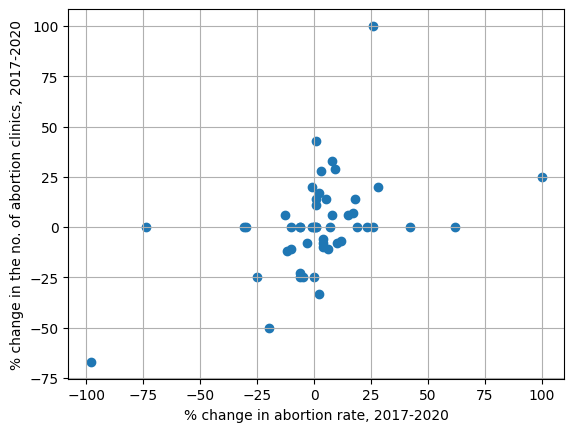

In [21]:
plt.scatter(x=df['% change in abortion rate, 2017-2020'], y=df['% change in the no. of abortion clinics, 2017-2020'])
plt.xlabel('% change in abortion rate, 2017-2020')
plt.ylabel('% change in the no. of abortion clinics, 2017-2020')
plt.grid()
plt.show()

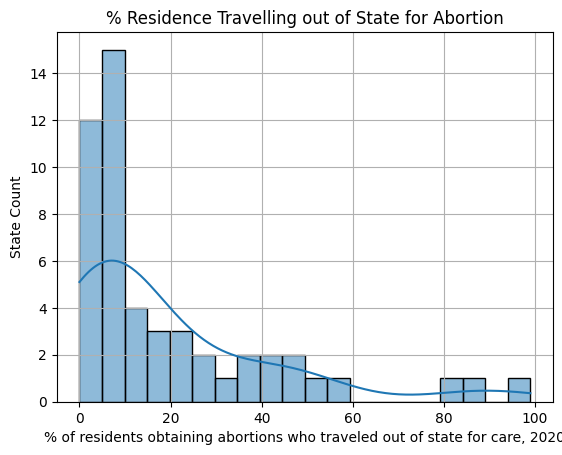

In [22]:
sns.histplot(
    df['% of residents obtaining abortions who traveled out of state for care, 2020'],
    bins=20,
    kde=True
)

plt.title('% Residence Travelling out of State for Abortion')
plt.ylabel('State Count')
plt.grid()
plt.show()

<Figure size 1000x1000 with 0 Axes>

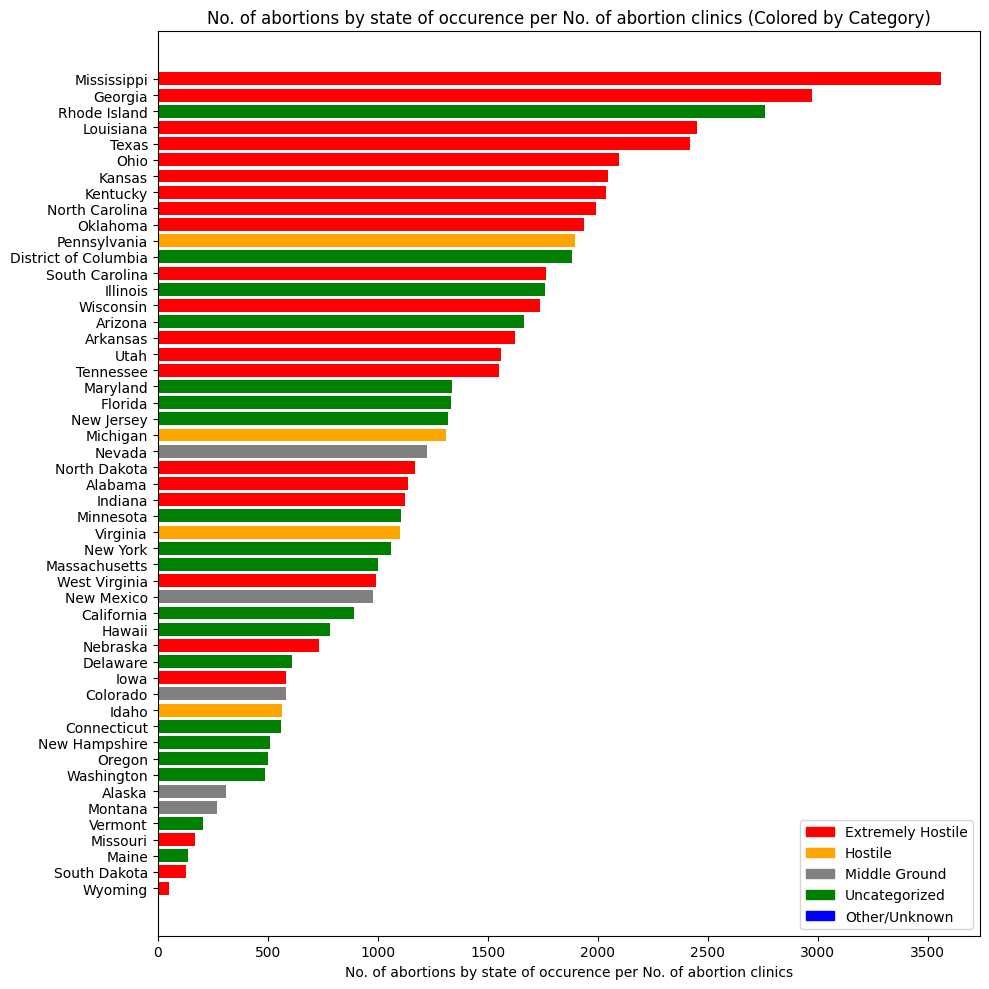

In [35]:
df['No. of abortions by state of occurence per No. of abortion clinics'] = df['No. of abortions, by state of occurrence, 2020'] / df['No. of abortion clinics, 2020'] 

plt.figure(figsize=(10, 10))

def get_color(state):
    if state in extremely_hostile_states:
        return "red"
    elif state in hostile_states:
        return "orange"
    elif state in middle_ground_states:
        return "gray"
    elif state in uncategorized_states:
        return "green"
    else:
        return "blue"
        
# Sort data
sorted_df = df.sort_values('No. of abortions by state of occurence per No. of abortion clinics', ascending=True)

# Assign colors
colors = [get_color(state) for state in sorted_df["U.S. State"]]

# Plot
plt.figure(figsize=(10, 10))
plt.barh(
    y=sorted_df["U.S. State"],
    width=sorted_df['No. of abortions by state of occurence per No. of abortion clinics'],
    color=colors
)
plt.xlabel('No. of abortions by state of occurence per No. of abortion clinics')
plt.title('No. of abortions by state of occurence per No. of abortion clinics (Colored by Category)')

# Create custom legend
legend_patches = [
    mpatches.Patch(color='red', label='Extremely Hostile'),
    mpatches.Patch(color='orange', label='Hostile'),
    mpatches.Patch(color='gray', label='Middle Ground'),
    mpatches.Patch(color='green', label='Uncategorized'),
    mpatches.Patch(color='blue', label='Other/Unknown')
]
plt.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()

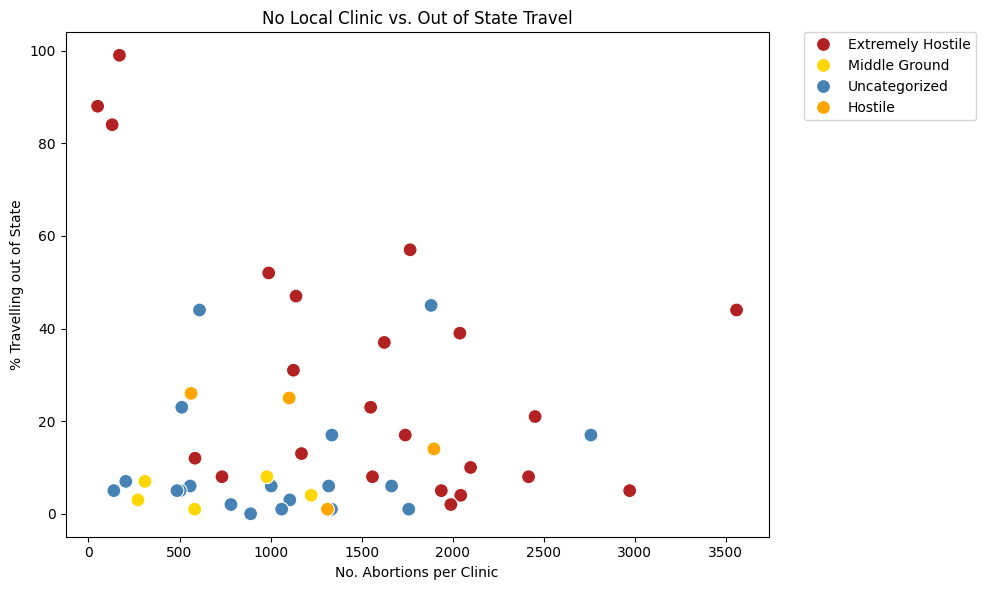

In [39]:
df['No. of abortions by state of occurence per No. of abortion clinics'] =df['No. of abortions, by state of occurrence, 2020'] /df['No. of abortion clinics, 2020'] 


def classify_state(state):
    if state in extremely_hostile_states:
        return 'Extremely Hostile'
    elif state in hostile_states:
        return 'Hostile'
    elif state in middle_ground_states:
        return 'Middle Ground'
    elif state in uncategorized_states:
        return 'Uncategorized'
    else:
        return 'Unknown'

df['Policy Category'] = df['U.S. State'].apply(classify_state)

custom_palette = {
    'Extremely Hostile': '#B22222',  # Firebrick / Dark Red
    'Hostile': '#FFA500',            # Orange
    'Middle Ground': '#FFD700',      # Gold
    'Uncategorized': '#4682B4'       # Steel Blue (or use 'gray')
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='No. of abortions by state of occurence per No. of abortion clinics',
    y='% of residents obtaining abortions who traveled out of state for care, 2020',
    hue='Policy Category',
    palette=custom_palette,  # optional: choose a palette with enough distinct colors
    s=100  # optional: set size of dots
)

plt.title('No Local Clinic vs. Out of State Travel')
plt.ylabel('% Travelling out of State')
plt.xlabel('No. Abortions per Clinic')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()